In [1]:
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cmocean as cmo
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import pylab as pl
import cartopy.mpl.geoaxes
import xarray as xr


In [3]:
coast='../datafiles/realistic'

file = sio.loadmat('../datafiles/N2_lin.mat')
N2 = file['N2']
z = np.arange(0, -3500, -10)

dsw = xr.open_dataset(str(coast)+'/Base.nc')
dsn = xr.open_dataset(str(coast)+'/BaseNo.nc')

LAT = dsw.YC
LON = dsw.XC - 360
Z = dsw.Z
hFacC = dsw.hFacC
hfa = np.ma.masked_values(hFacC[0, :, :], 0)
mask = np.ma.getmask(hfa)

depth = dsw.Depth
depthno = dsn.Depth
rho = dsw.rhoRef

ind_lon = [-115.11813068276555, -115.939167, -116.605833, -117.1625, -118.24368, -119.714167, -120.471439,
           -120.7586085906775]
ind_lat = [27.850440699318973, 30.556389, 31.857778, 32.715, 34.05223, 34.425833, 34.448113, 35.17364705813524]


/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_90548/2543914399.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dsw = xr.open_dataset(str(coast)+'/Base.nc')
/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_90548/2543914399.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dsn = xr.open_dataset(str(coast)+'/BaseNo.nc')


In [4]:
lon_start=-115.54
lon_end=-118.13
lat_start=29.96
lat_end=33.45

In [5]:
def plot_square(x_start, y_start, x_end,y_end,ax):
    """Plots a square by defining its four corners and connecting them with lines."""
    x_coords = [x_start, x_end, x_end, x_start,x_start]
    y_coords = [y_start, y_start, y_end, y_end, y_start]
    
    ax.plot(x_coords, y_coords, color='white', linewidth=2,linestyle='solid')
    

In [6]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 4.5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:394: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/shapely/predicates.py:806: Runtim

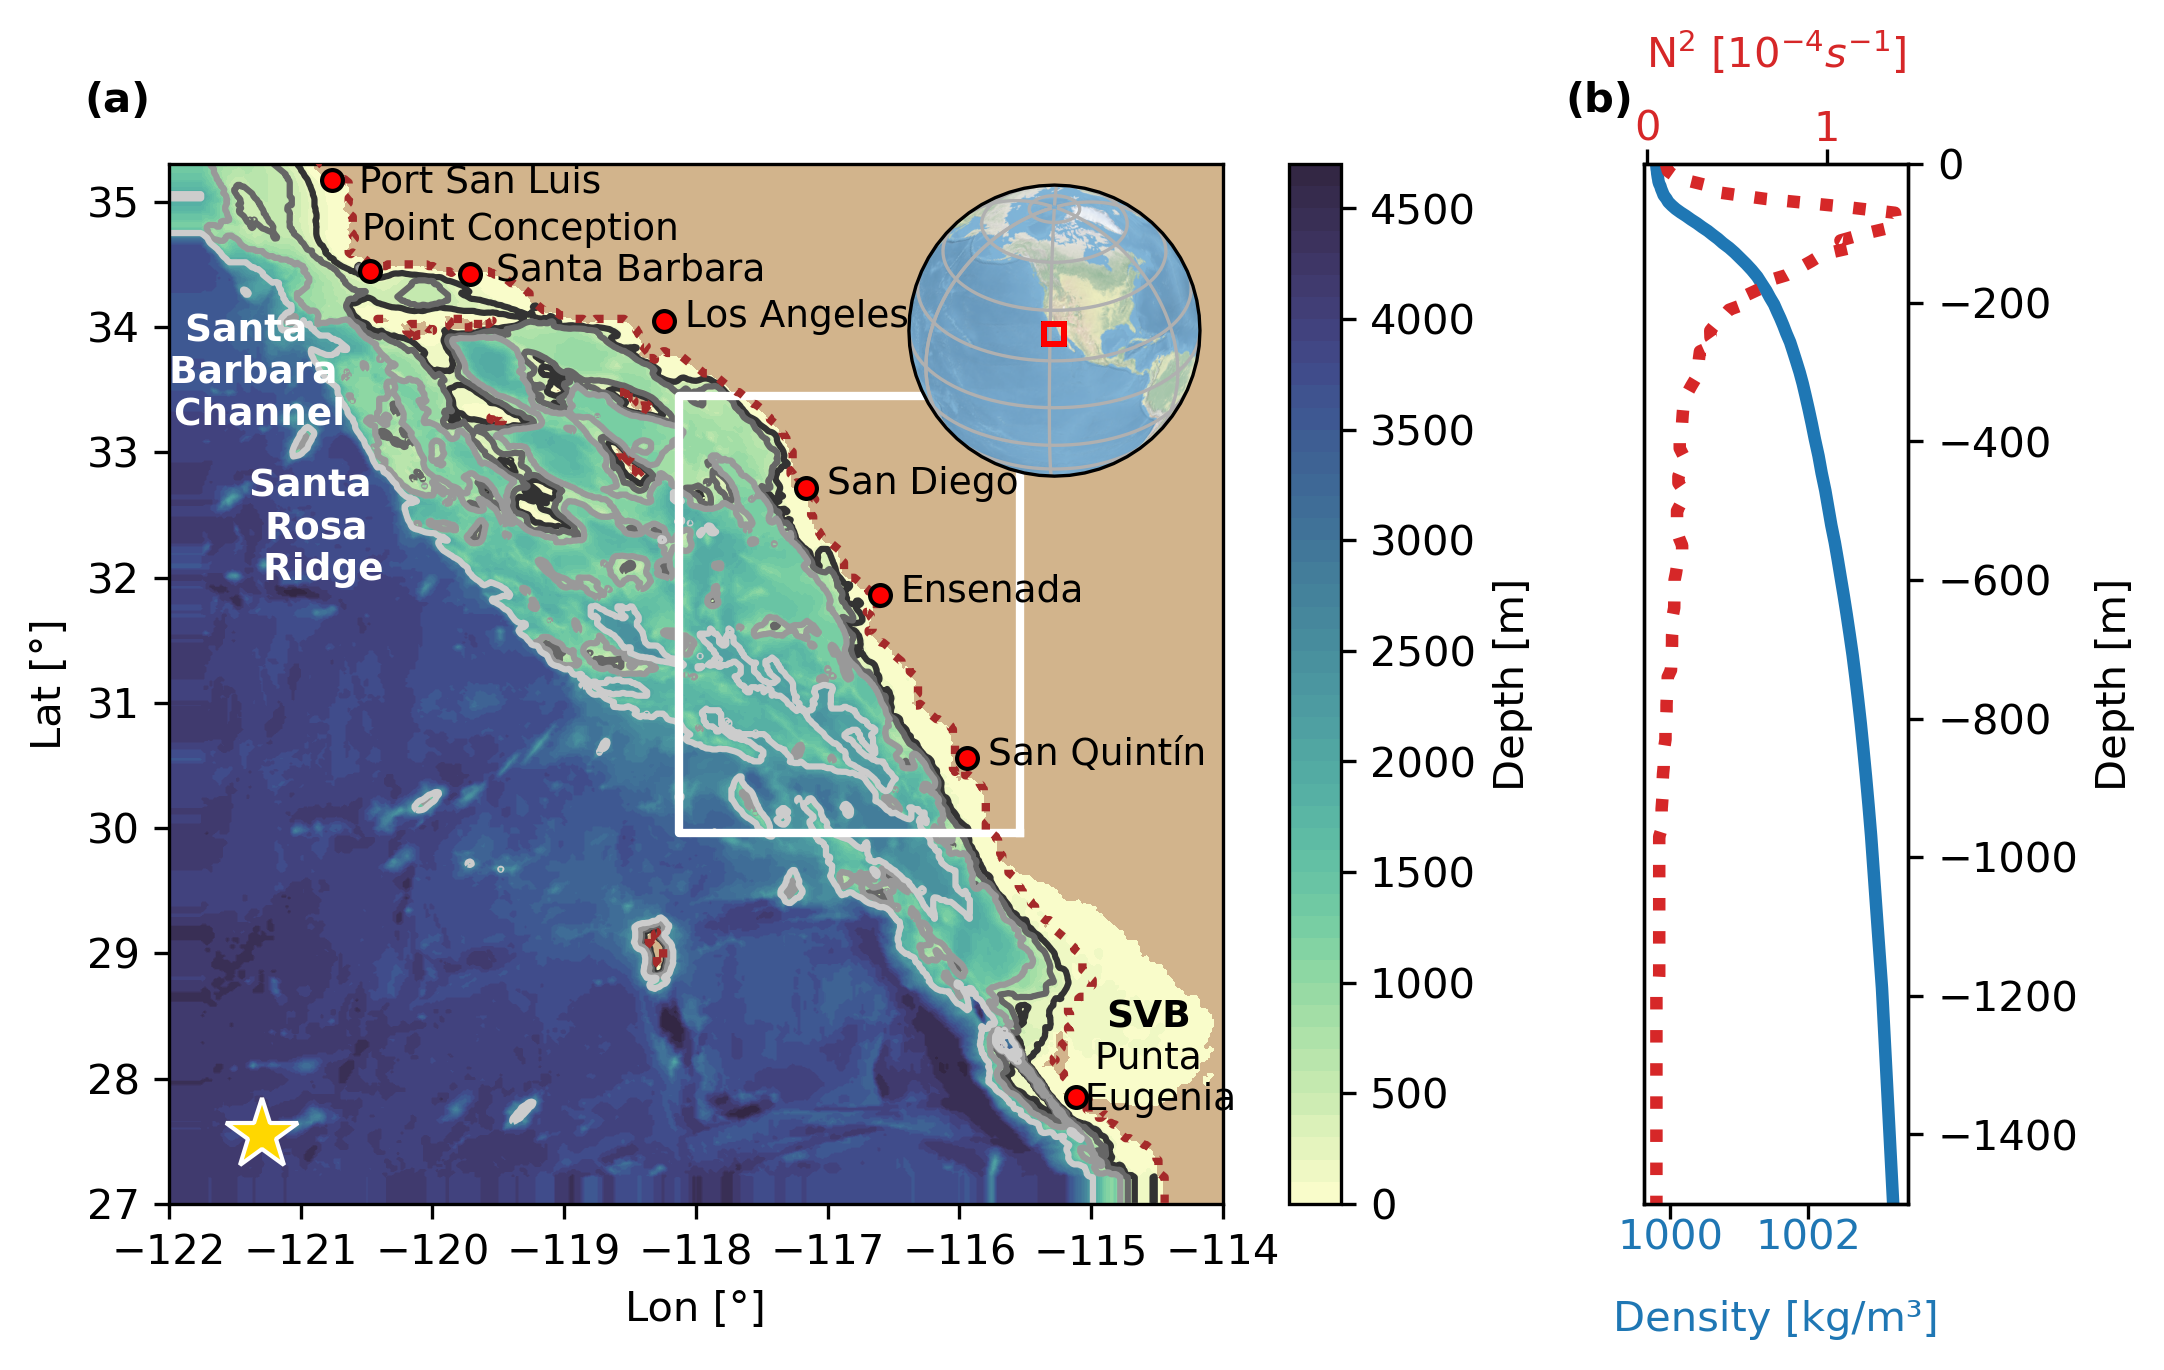

In [7]:
fig = plt.figure()
gs = GridSpec(nrows=2, ncols=2, width_ratios=[2.5, 0.5])

mssq=5
msst=18
ms=5
fs=9
ax = fig.add_subplot(gs[0:, 0])
ax.set_facecolor('tan')

pc = ax.contourf(LON, LAT, np.ma.masked_array(depth, mask=mask), 50,
                 vmin=0, vmax=5000, cmap=cmo.cm.deep, zorder=1) 

cb = plt.colorbar(pc)  
cn = ax.contour(LON, LAT, depth, colors=['0.2', '0.4', '0.6', '0.8'],
                levels=[200, 500, 1000, 2000], zorder=2)
cb.set_label('Depth [m]')
ax.contour(LON, LAT, depthno, levels=[0], colors='brown', linestyles=':', linewidths=2, zorder=3)

axins = inset_axes(ax, width="28%", height="28%", loc='upper right',
                   axes_class=cartopy.mpl.geoaxes.GeoAxes,
                   axes_kwargs=dict(map_projection=cartopy.crs.Orthographic(central_latitude=32,
                                                                            central_longitude=-118)))
axins.add_feature(cartopy.feature.OCEAN, zorder=0)
axins.add_feature(cartopy.feature.LAND, zorder=0, edgecolor='black')
axins.gridlines()
axins.stock_img()

axins.plot(LON, np.ones_like(LON) * 35.3, 's', color='r', markersize=mssq, fillstyle='none',
           transform=cartopy.crs.Orthographic(-118, 30.7))


plot_square(lon_start, lat_start, lon_end,lat_end,ax)
for kk, ll, lab in zip(ind_lon, ind_lat,
                       ['Punta \n Eugenia', 'San Quintín', 'Ensenada', 'San Diego', 'Los Angeles', 'Santa Barbara',
                        'Point Conception', 'Port San Luis']):
	ax.plot(kk, ll, 'o',markersize=ms, color='r', markeredgecolor='k',zorder=5)
	if lab == 'Point Conception':
		ax.text(kk - 0.06, ll + 0.25, lab, fontsize=fs)
	elif lab == 'Santa Barbara':
		ax.text(kk + 0.2, ll - 0.05, lab, fontsize=fs)
	elif lab == 'Port San Luis':
		ax.text(kk + 0.2, ll - 0.1, lab, fontsize=fs)
	elif lab == 'Punta \n Eugenia':
		ax.text(kk + 0.6, ll - 0.1, lab, fontsize=fs, horizontalalignment='center')
	else:
		ax.text(kk + 0.16, ll - 0.05, lab, fontsize=fs)


ax.text(0.93, 0.17, 'SVB', fontsize=fs, horizontalalignment='center', fontweight='bold',
        transform=ax.transAxes)
        
ax.plot(LON[45], LAT[40], '*', color='gold', markersize=msst, markeredgecolor='w')

ax.text(0.08, 0.75, 'Santa \n Barbara \n Channel', color='w', fontsize=fs, transform=ax.transAxes,
        fontweight='demibold', horizontalalignment='center')
ax.text(0.14, 0.6, 'Santa \n Rosa \n Ridge', color='w', fontsize=fs, transform=ax.transAxes,
        fontweight='bold', horizontalalignment='center')
hej = [58, 85, 205, 227]

markers = Line2D.filled_markers
markers = np.delete(markers, np.arange(2, 5, 1))
colors = ['b', 'g', 'r', 'k', 'm', 'c', 'y', 'brown', 'lime', 'fuchsia', 'beige']

ax.set_xlabel('Lon [°]')
ax.set_ylabel('Lat [°]')
ax.set_xlim(238 - 360, 246 - 360)
ax.set_ylim(27, 35.3)

ax.text(-0.08, 1.05, '(a)', fontweight='bold', color='k',
        transform=ax.transAxes)

lw=3
ax1 = fig.add_subplot(gs[0:, 1])
ax1.plot(rho[Z >= -1800], Z[Z >= -1800], 'tab:blue', linewidth=lw)
ax1.set_xlabel('Density [kg/m³]', color='tab:blue', labelpad=10)
ax1.tick_params(axis='x', labelcolor='tab:blue', pad=0)
ax1.set_ylabel('Depth [m]')
ax1.set_ylim(-1500, 0)
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position("right")

ax2 = ax1.twiny()
ax2.plot(N2[z >= -1500] * 10 ** 4, z[z >= -1500], linestyle=':', color='tab:red', linewidth=lw)
ax2.tick_params(axis='x', labelcolor='tab:red', pad=0)
ax2.set_xlabel('N$^2$ [$10^{-4} s^{-1}$]', color='tab:red', labelpad=10)
ax2.text(-0.3, 1.05, '(b)', fontweight='bold',
         color='k', transform=ax2.transAxes)


plt.savefig('../figures/MAP_fig1.pdf')

